<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype                    
---  ------      --------------    -----                    
 0   Unnamed: 0  1407328 non-null  int64                    
 1   headline    1407328 non-null  object                   
 2   url         1407328 non-null  object                   
 3   publisher   1407328 non-null  object                   
 4   date        55987 non-null    datetime64[ns, UTC-04:00]
 5   stock       1407328 non-null  object                   
dtypes: datetime64[ns, UTC-04:00](1), int64(1), object(4)
memory usage: 64.4+ MB
None
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Fr

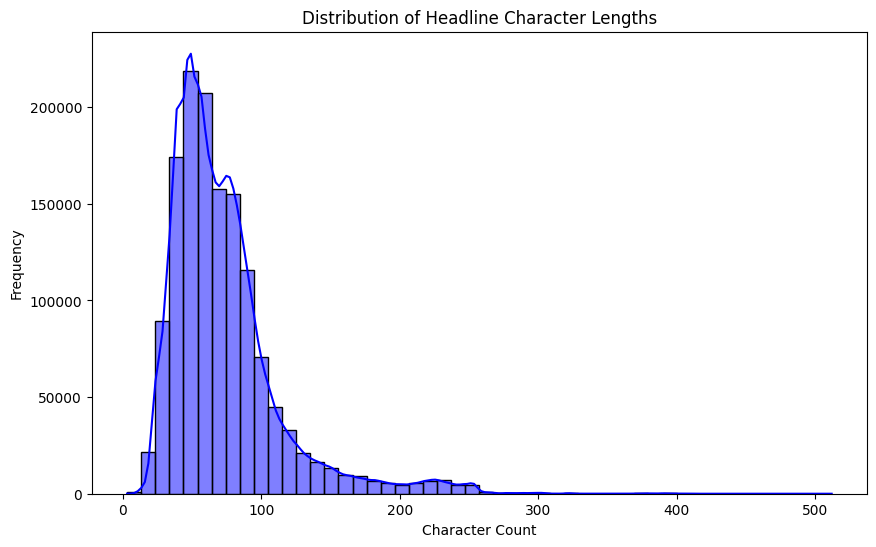

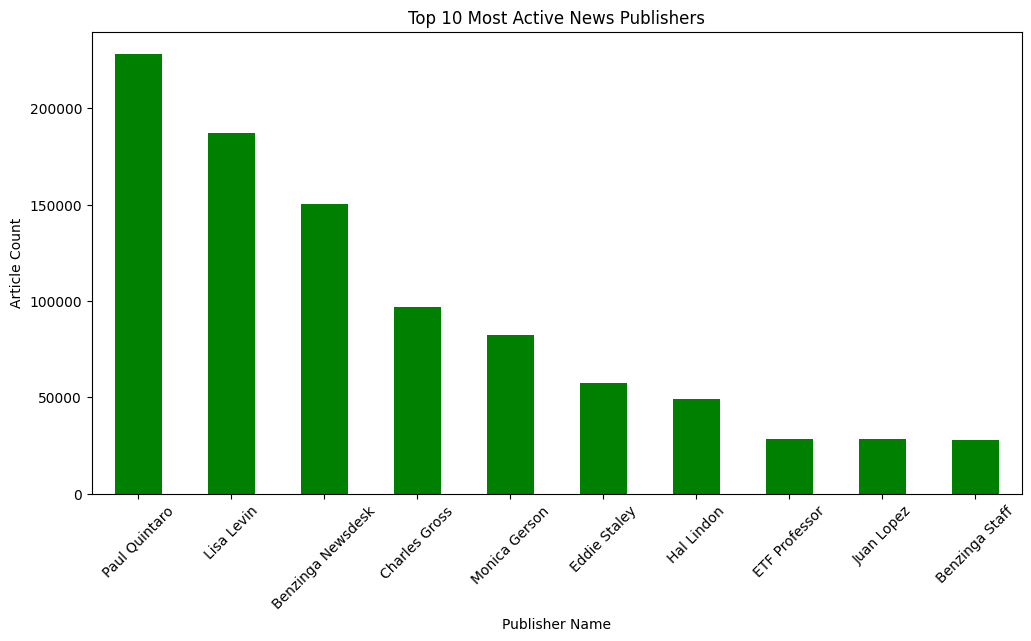

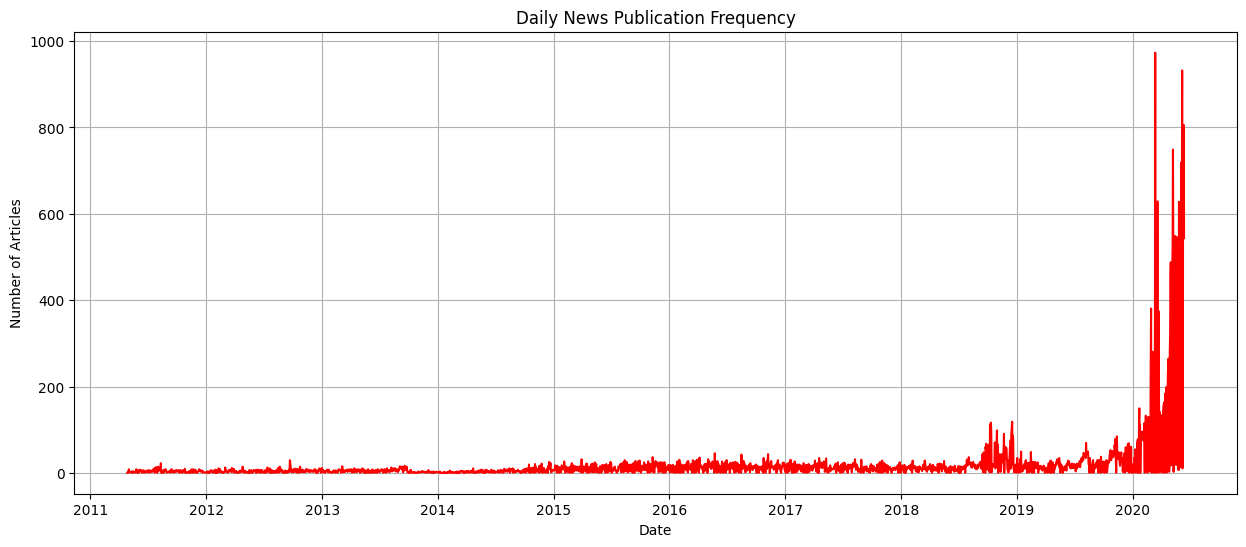

Top Recurring Keywords/Themes:
['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the financial news dataset
# Replace 'raw_analyst_ratings.csv' with the actual name of your unzipped file
import os
file_path = '../data/raw/raw_analyst_ratings.csv'
if not os.path.exists(file_path):
    file_path = './data/raw/raw_analyst_ratings.csv'

df = pd.read_csv(file_path)

# Convert 'date' to datetime for time-series analysis [cite: 110]
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Display basic info to check for missing values [cite: 135]
print(df.info())
print(df.head())

# Calculate character length of each headline
df['headline_len'] = df['headline'].apply(len)

# Statistical summary of lengths
print(df['headline_len'].describe())

# Visualization 1: Headline Length Distribution [cite: 128]
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True, color='blue')
plt.title('Distribution of Headline Character Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

# Visualization 2: Top 10 Publishers [cite: 128]
plt.figure(figsize=(12, 6))
publisher_counts.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Most Active News Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Article Count')
plt.xticks(rotation=45)
plt.show()

# If publishers are emails, extract domains [cite: 121]
# df['domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')
# print(df['domain'].value_counts().head(5))

# Group news volume by date
daily_counts = df.groupby(df['date'].dt.date).size()

# Visualization 3: News Volume Over Time [cite: 128]
plt.figure(figsize=(15, 6))
daily_counts.plot(kind='line', color='red')
plt.title('Daily News Publication Frequency')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

# Use TF-IDF to find common keywords [cite: 114]
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = vectorizer.fit_transform(df['headline'].dropna())

# Get the top keywords
keywords = vectorizer.get_feature_names_out()
print("Top Recurring Keywords/Themes:")
print(keywords)

1. Analysis of Headline Lengths
Markdown Cell Content:

Finding: The distribution of headline character counts is heavily right-skewed.

Interpretation: Most headlines are concentrated between 40 and 100 characters, indicating that financial news is optimized for quick consumption on mobile terminals and dashboards.

Outliers: There are several headlines extending beyond 250 characters. These represent specialized technical reports or long-form regulatory filing summaries (like SEC 8-K filings) that contain more detail than a standard news "flash."

2. Publisher Contribution Analysis
Markdown Cell Content:

Finding: The dataset is dominated by individual contributors and the Benzinga Newsdesk. Paul Quintaro and Lisa Levin are the most prolific authors, collectively accounting for over 400,000 articles.

Interpretation: The presence of specific names like Paul Quintaro (Benzinga's co-founder) and Lisa Levin (Associate Editor) indicates a high volume of analyst-driven content. This means the sentiment analysis in Task 3 will be heavily influenced by the "Benzinga style" of reporting, which often focuses on mid-day movers and technical breakouts.

3. News Volume & Market Events (Time Series)
Markdown Cell Content:

Finding: The news volume remained relatively flat from 2011 to 2018, followed by an extreme surge in early 2020, peaking at nearly 1,000 articles per day.

Contextual Research:

The 2020 Surge: The massive spike in the red line corresponds exactly with the COVID-19 Financial Panic (February–March 2020).

Market Drivers: During this period, the market saw "Black Monday I" (March 9) and "Black Thursday" (March 12), where record volatility triggered a flood of news as companies rushed to update guidance and analysts tracked the unprecedented 12% daily drops.

Interpretation: This dataset is highly relevant for "stress-testing" sentiment analysis because it contains a massive amount of data during a period of peak global uncertainty.

4. Keyword/Theme Analysis
Markdown Cell Content:

Finding: The recurring keywords—'earnings', 'eps', 'est', 'shares', 'price', and 'downgrades'—confirm that the dataset is strictly focused on equity valuation and fundamental performance.

Interpretation: The dominance of terms like 'eps' (Earnings Per Share) and 'est' (Estimates) shows that the headlines are built around matching analyst expectations. This will be critical for Task 3, as "earnings beats" or "downgrades" usually drive the most significant stock price movements.